In [16]:
# Installe scikit-posthocs (test post-hoc de Dunn) s'il n'est pas déjà présent
!pip install scikit-posthocs --quiet

## Variables disponibles dans le dataset

| Variable | Description | Disponible en prod ? | Type | Taux manquant | Distribution/Détails |
|---|---|---|---|---|---|
| Images (PNG) | Radiographie pulmonaire | Oui | Image 299×299, niveaux de gris | 0% | Voir distribution par classe |
| Masques | Segmentation poumons | Oui | Image 256×256, binaire | 0% | Nécessite resize pour matcher l'image |
| FILE NAME | Identifiant image | Oui | string | 0% | — |
| URL (métadonnées) | Source de l'image | Non en prod | string | 0% | 4 sources hétérogènes pour COVID (SIRM, Github, PadChest, Autre) |
| Classe (dossier) | Label cible à prédire |  | catégorielle | 0% | Normal: 10192, Lung Opacity: 6012, COVID: 3616, Viral Pneumonia: 1345 |

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
covid = pd.read_excel(r'C:\Users\Maxime\Desktop\Projet COVID19\COVID-19_Radiography_Dataset\COVID.metadata.xlsx')
normal = pd.read_excel(r'C:\Users\Maxime\Desktop\Projet COVID19\COVID-19_Radiography_Dataset\Normal.metadata.xlsx')
lung = pd.read_excel(r'C:\Users\Maxime\Desktop\Projet COVID19\COVID-19_Radiography_Dataset\Lung_Opacity.metadata.xlsx')
pneumonia = pd.read_excel(r'C:\Users\Maxime\Desktop\Projet COVID19\COVID-19_Radiography_Dataset\Viral Pneumonia.metadata.xlsx')

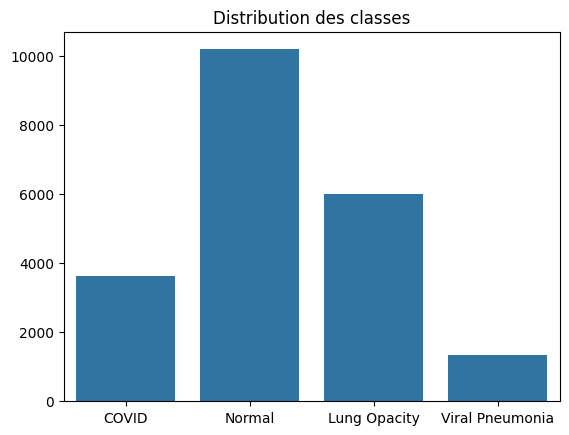

In [19]:
classes = {'COVID': len(covid), 'Normal': len(normal), 
           'Lung Opacity': len(lung), 'Viral Pneumonia': len(pneumonia)}
sns.barplot(x=list(classes.keys()), y=list(classes.values()))
plt.title("Distribution des classes")
plt.show()

## Distribution des classes

Le dataset présente un déséquilibre important entre les classes :
- Normal est très majoritaire (10 192 images)
- Viral Pneumonia est très minoritaire (1 345 images)

Ce déséquilibre devra être pris en compte lors de la modélisation 
(data augmentation, class weights).

## Source des images

Les images COVID proviennent de 4 sources différentes :
- 2473 images de PadChest
- 183 images d'une école médicale allemande
- 559 images de SIRM, Github, Kaggle
- 400 images d'une autre source Github

Le modèle pourrait apprendre des artefacts techniques 
propres à chaque source plutôt que les caractéristiques médicales du Covid.

Normalisation des images en pre-processing ?

In [20]:
def get_source(url):
    if 'sirm' in str(url): return 'SIRM'
    elif 'github' in str(url): return 'Github'
    elif 'kaggle' in str(url): return 'Kaggle'
    elif 'padchest' in str(url) or 'bimcv' in str(url): return 'PadChest'
    elif 'figshare' in str(url): return 'Figshare'
    else: return 'Autre'

covid['source'] = covid['URL'].apply(get_source)
covid['source'].value_counts()

source
PadChest    2474
Github       765
Autre        258
SIRM         119
Name: count, dtype: int64

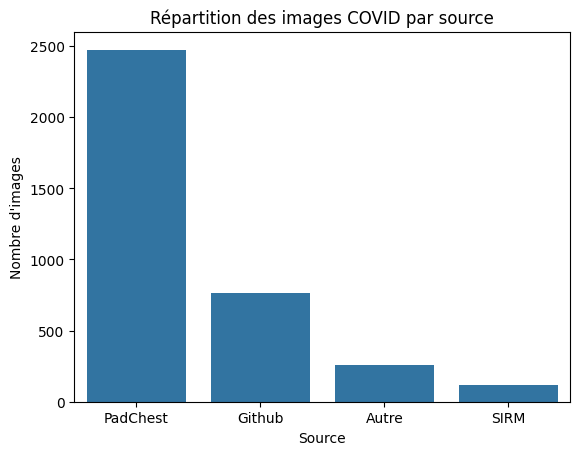

In [21]:
sns.barplot(x=covid['source'].value_counts().index, 
            y=covid['source'].value_counts().values)
plt.title("Répartition des images COVID par source")
plt.xlabel("Source")
plt.ylabel("Nombre d'images")
plt.show()

In [22]:
import cv2

base = r"C:\Users\Maxime\Desktop\Projet COVID19\COVID-19_Radiography_Dataset"

img = cv2.imread(base + r"\COVID\images\COVID-1.png")
mask = cv2.imread(base + r"\COVID\masks\COVID-1.png")

print("Image :", img.shape)
print("Masque :", mask.shape)

Image : (299, 299, 3)
Masque : (256, 256, 3)


In [23]:
def get_source(url):
    if 'sirm' in str(url): return 'SIRM'
    elif 'github' in str(url): return 'Github'
    elif 'kaggle' in str(url): return 'Kaggle'
    elif 'padchest' in str(url) or 'bimcv' in str(url): return 'PadChest'
    elif 'figshare' in str(url): return 'Figshare'
    else: return 'Autre'

covid['source'] = covid['URL'].apply(get_source)

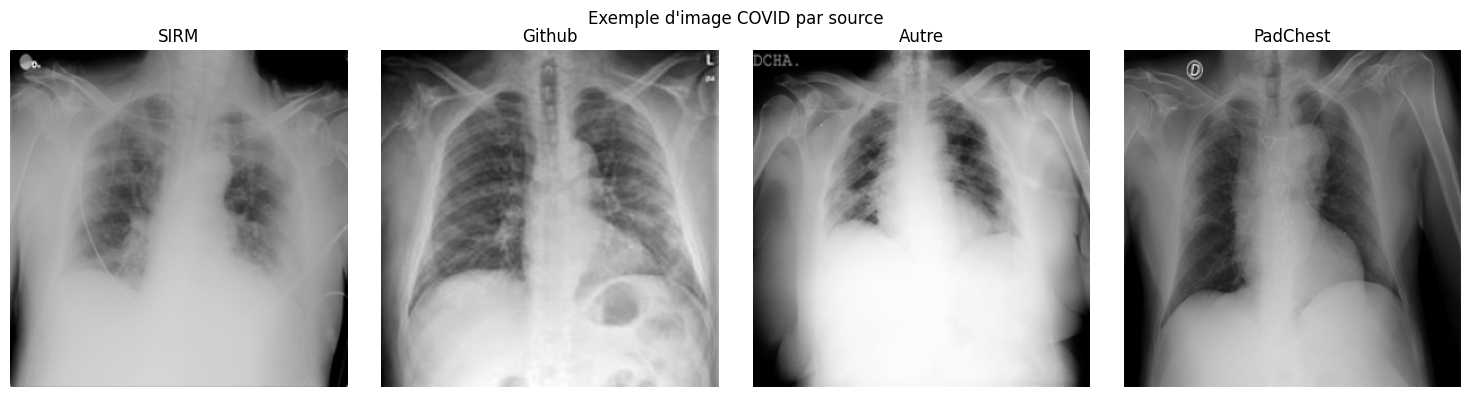

In [24]:
import cv2

base_path = r"C:\Users\Maxime\Desktop\Projet COVID19\COVID-19_Radiography_Dataset"
sources = covid['source'].unique()

fig, axes = plt.subplots(1, len(sources), figsize=(15, 4))

for i, source in enumerate(sources):
    fichier = covid[covid['source'] == source]['FILE NAME'].iloc[0]
    img_path = base_path + r"\COVID\images\\" + fichier + ".png"
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(source)
    axes[i].axis('off')

plt.suptitle("Exemple d'image COVID par source")
plt.tight_layout()
plt.show()

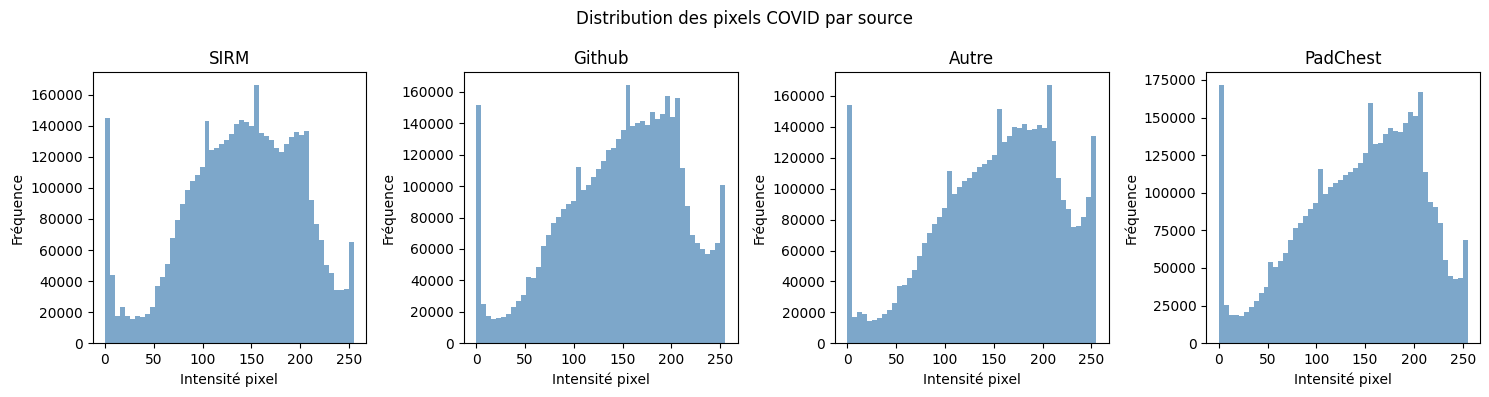

In [25]:
fig, axes = plt.subplots(1, len(sources), figsize=(15, 4))

for i, source in enumerate(sources):
    # Récupère toutes les images de cette source
    fichiers = covid[covid['source'] == source]['FILE NAME'].tolist()
    
    # Charge les pixels des 50 premières images pour aller vite
    pixels = []
    for fichier in fichiers[:50]:
        img_path = base_path + r"\COVID\images\\" + fichier + ".png"
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            pixels.extend(img.flatten().tolist())
    
    axes[i].hist(pixels, bins=50, color='steelblue', alpha=0.7)
    axes[i].set_title(source)
    axes[i].set_xlabel('Intensité pixel')
    axes[i].set_ylabel('Fréquence')

plt.suptitle("Distribution des pixels COVID par source")
plt.tight_layout()
plt.show()

In [26]:
# Moyenne et écart-type des pixels par source
stats = []
for source in sources:
    fichiers = covid[covid['source'] == source]['FILE NAME'].tolist()
    pixels = []
    for fichier in fichiers[:50]:
        img_path = base_path + r"\COVID\images\\" + fichier + ".png"
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            pixels.extend(img.flatten().tolist())
    stats.append({
        'Source': source,
        'Moyenne': np.mean(pixels),
        'Écart-type': np.std(pixels)
    })

stats_pixels_df = pd.DataFrame(stats)
stats_pixels_df

,Source,Moyenne,Écart-type
0,SIRM,139.831856,59.144322
1,Github,147.094942,61.498938
2,Autre,152.612241,62.903397
3,PadChest,143.993556,62.373686


### Moyenne et écart-type de la distribution des pixels

Le tableau affiché sous les histogrammes récapitule, pour chaque source, la **moyenne**
d'intensité des pixels et leur **écart-type**.

**Lecture des résultats :**
- Une **moyenne** comparable entre les sources indique un niveau de luminosité global similaire.
- Un **écart-type plus élevé** signale une distribution plus étalée, donc des images au contraste
  plus variable (mélange de zones très sombres et très claires). Un écart-type plus faible traduit
  des images plus homogènes en intensité.
- Comparer ces deux statistiques entre sources permet de repérer rapidement laquelle s'écarte
  des autres et pourrait introduire un biais technique, ce qui confirme ou nuance l'observation
  visuelle des histogrammes.

## Analyse de la distribution des pixels COVID par source

### Méthodologie
Pour chaque source (SIRM, Github, Autre, PadChest), nous avons :
1. Sélectionné les 50 premières images COVID de cette source
2. Chargé chaque image en niveaux de gris (valeurs de 0 à 255)
3. **Sans application des masques** : les images brutes sont analysées ici
4. Aplati les pixels en listes et tracé leur distribution

### Interprétation des valeurs
- **0 (noir)** : fond de l'image, zones hors poumons, ou zones masquées
- **1-100 (gris sombre)** : tissus pulmonaires sains, zones peu denses
- **100-200 (gris moyen)** : structures pulmonaires, vaisseaux
- **200-255 (blanc)** : zones très denses comme les os (côtes, colonne), les opacités
  pathologiques, ou potentiellement des annotations et artefacts médicaux

### Observations
- Les 4 sources ont des profils globalement similaires, ce qui est rassurant pour l'homogénéité du dataset
- **PadChest** se distingue avec un pic à 0 plus élevé, soit une proportion plus importante
  de pixels noirs, ce qui suggère des images avec plus de fond ou un cadrage différent
- Les pics à 255 présents dans toutes les sources indiquent des zones très blanches
  potentiellement liées à des artefacts ou annotations radiologiques
- L'hétérogénéité reste limitée : une normalisation en pre-processing devrait suffire
  à harmoniser les sources

In [27]:
import cv2

# Luminosité moyenne sur TOUTES les images COVID (les 3616), pour 3 zones :
#   - "image totale"      : moyenne sur l'image brute complète, sans masque
#   - "intérieur masque"  : moyenne sur les pixels où le masque vaut 1 (poumons)
#   - "extérieur masque"  : moyenne sur les pixels où le masque vaut 0 (reste de l'image)
# Le traitement de 3616 images prend un peu de temps -> print de progression toutes les 200.

lum_totale, lum_interieur, lum_exterieur = [], [], []

fichiers = covid['FILE NAME'].tolist()
n = len(fichiers)

for i, f in enumerate(fichiers):
    img = cv2.imread(base_path + r"\COVID\images\\" + f + ".png", cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(base_path + r"\COVID\masks\\" + f + ".png", cv2.IMREAD_GRAYSCALE)

    # Image totale : moyenne sur l'image brute complète
    lum_totale.append(img.mean())

    # Redimensionnement du masque (256x256) à la taille de l'image (299x299),
    # au plus proche voisin pour conserver un masque binaire, puis binarisation.
    mask = cv2.resize(mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
    mask_bin = mask > 127  # True = intérieur (poumons), False = extérieur (fond)

    # Intérieur du masque : moyenne uniquement sur les pixels du masque (== 1)
    lum_interieur.append(img[mask_bin].mean() if mask_bin.any() else np.nan)
    # Extérieur du masque : moyenne uniquement sur les pixels hors masque (== 0)
    lum_exterieur.append(img[~mask_bin].mean() if (~mask_bin).any() else np.nan)

    if (i + 1) % 200 == 0:
        print(f"{i + 1} / {n} images traitées")

print(f"Terminé : {n} images traitées")

covid['lum_totale'] = lum_totale
covid['lum_interieur'] = lum_interieur
covid['lum_exterieur'] = lum_exterieur

200 / 3616 images traitées
400 / 3616 images traitées
600 / 3616 images traitées
800 / 3616 images traitées
1000 / 3616 images traitées
1200 / 3616 images traitées
1400 / 3616 images traitées
1600 / 3616 images traitées
1800 / 3616 images traitées
2000 / 3616 images traitées
2200 / 3616 images traitées
2400 / 3616 images traitées
2600 / 3616 images traitées
2800 / 3616 images traitées
3000 / 3616 images traitées
3200 / 3616 images traitées
3400 / 3616 images traitées
3600 / 3616 images traitées
Terminé : 3616 images traitées


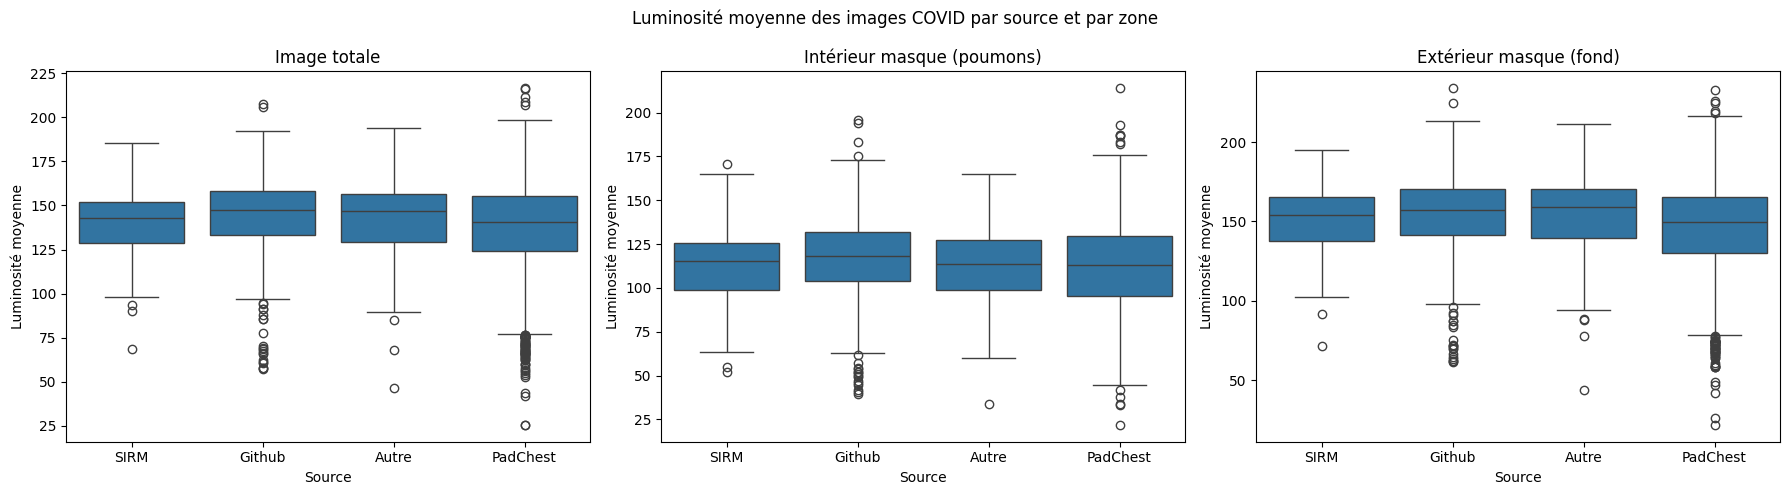

In [28]:
zones = [
    ('lum_totale',    'Image totale'),
    ('lum_interieur', 'Intérieur masque (poumons)'),
    ('lum_exterieur', 'Extérieur masque (fond)'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (col, titre) in zip(axes, zones):
    sns.boxplot(x='source', y=col, data=covid, ax=ax)
    ax.set_title(titre)
    ax.set_xlabel("Source")
    ax.set_ylabel("Luminosité moyenne")

plt.suptitle("Luminosité moyenne des images COVID par source et par zone")
plt.tight_layout()
plt.show()

### Lecture du graphique

Les trois boxplots montrent des distributions de luminosité globalement 
comparables entre sources, avec une médiane plus basse à l'intérieur du 
masque (~115-120, zone pulmonaire moins dense) qu'à l'extérieur (~150-160, 
zone incluant les structures osseuses et le fond).

PadChest se distingue visuellement dans les trois zones par une dispersion 
plus importante, avec de nombreuses valeurs aberrantes vers le bas (images 
particulièrement sombres). Cette observation visuelle est cohérente avec sa 
sur-représentation dans le dataset (68% des images COVID), mais aussi avec 
les résultats des tests statistiques qui suivent.

## Test statistique : Kruskal-Wallis

On veut savoir si la luminosité moyenne diffère réellement entre les 4 sources, ou si les
écarts observés sur les boxplots ne sont que le fruit du hasard.

**Hypothèses :**
- **H0** : les 4 sources ont la même distribution de luminosité (mêmes médianes) ; les écarts
  observés ne sont dus qu'au hasard de l'échantillonnage.
- **H1** : au moins une source a une distribution de luminosité différente des autres.

**Pourquoi Kruskal-Wallis plutôt qu'une ANOVA ?**
L'ANOVA à un facteur suppose que, dans chaque groupe, les données suivent une loi **normale**
et que les variances sont **homogènes** entre groupes (homoscédasticité). Ces conditions ne sont
pas réunies ici : les distributions de luminosité sont asymétriques, très étalées et truffées de
valeurs aberrantes (notamment PadChest, voir les boxplots), et les variances diffèrent nettement
d'une source à l'autre. Dans ces conditions, la p-value d'une ANOVA serait peu fiable.

Le **test de Kruskal-Wallis** est l'équivalent **non paramétrique** de l'ANOVA : il travaille sur
les **rangs** des valeurs plutôt que sur les valeurs elles-mêmes. Il ne suppose ni normalité ni
égalité des variances et reste robuste aux valeurs extrêmes, ce qui le rend mieux adapté à nos
données.

Si la p-value est inférieure au seuil de 5 %, on rejette H0 : la luminosité diffère
significativement selon la source.

In [29]:
from scipy.stats import kruskal

# 3 tests de Kruskal-Wallis (un par zone), sur l'ensemble des 3616 images.
# Pour chaque zone : la luminosité moyenne diffère-t-elle entre les 4 sources ?
zones = [
    ('lum_totale',    'Image totale'),
    ('lum_interieur', 'Intérieur masque (poumons)'),
    ('lum_exterieur', 'Extérieur masque (fond)'),
]
alpha = 0.05

for col, titre in zones:
    # On regroupe les luminosités par source (en retirant d'éventuels NaN)
    groupes = [covid[covid['source'] == s][col].dropna().values for s in sources]

    stat_h, p_value = kruskal(*groupes)

    print(f"=== {titre} ===")
    print(f"Statistique H : {stat_h:.4f}")
    print(f"p-value       : {p_value:.4e}")
    if p_value < alpha:
        print(f"=> p-value < {alpha} : différence SIGNIFICATIVE de luminosité "
              f"entre les sources.")
        print("   Au moins une source a une luminosité différente des autres.\n")
    else:
        print(f"=> p-value >= {alpha} : différence NON significative de luminosité "
              f"entre les sources.")
        print("   On ne peut pas conclure à une différence de luminosité entre les sources.\n")

=== Image totale ===
Statistique H : 45.4239
p-value       : 7.5191e-10
=> p-value < 0.05 : différence SIGNIFICATIVE de luminosité entre les sources.
   Au moins une source a une luminosité différente des autres.

=== Intérieur masque (poumons) ===
Statistique H : 32.2691
p-value       : 4.5927e-07
=> p-value < 0.05 : différence SIGNIFICATIVE de luminosité entre les sources.
   Au moins une source a une luminosité différente des autres.

=== Extérieur masque (fond) ===
Statistique H : 70.1994
p-value       : 3.8686e-15
=> p-value < 0.05 : différence SIGNIFICATIVE de luminosité entre les sources.
   Au moins une source a une luminosité différente des autres.



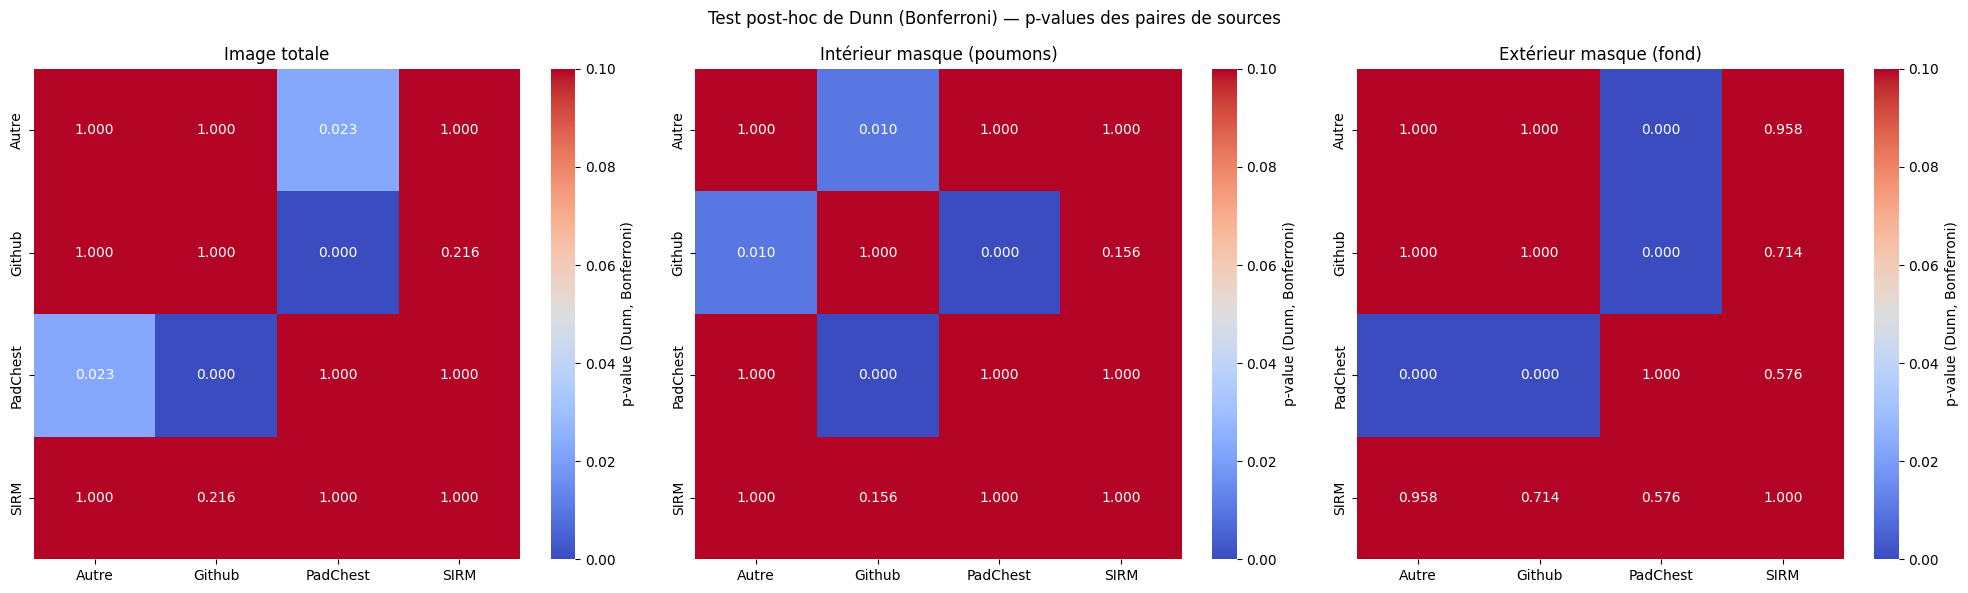

In [30]:
import scikit_posthocs as sp

# Test post-hoc de Dunn (correction de Bonferroni) pour chaque zone :
# quelles PAIRES de sources diffèrent significativement ?
zones = [
    ('lum_totale',    'Image totale'),
    ('lum_interieur', 'Intérieur masque (poumons)'),
    ('lum_exterieur', 'Extérieur masque (fond)'),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (col, titre) in zip(axes, zones):
    # Données propres (sans NaN) pour la zone
    df_zone = covid[['source', col]].dropna()

    # Matrice carrée des p-values des comparaisons paire à paire
    dunn = sp.posthoc_dunn(df_zone, val_col=col, group_col='source',
                           p_adjust='bonferroni')

    # Heatmap : colormap divergent centré sur le seuil 0.05.
    # Côté bleu/froid (p < 0.05) = paire significativement différente,
    # côté rouge/chaud (p >= 0.05) = paire non significative.
    sns.heatmap(dunn, annot=True, fmt=".3f", cmap='coolwarm',
                center=0.05, vmin=0, vmax=0.1, ax=ax,
                cbar_kws={'label': 'p-value (Dunn, Bonferroni)'})
    ax.set_title(titre)

plt.suptitle("Test post-hoc de Dunn (Bonferroni) — p-values des paires de sources")
plt.tight_layout()
plt.show()

## Interprétation des tests post-hoc de Dunn

Les tests de Kruskal-Wallis ayant révélé une différence significative entre 
sources pour les 3 zones étudiées, le test post-hoc de Dunn (avec correction 
de Bonferroni) permet d'identifier précisément quelles paires de sources 
diffèrent entre elles.

**Image totale** : une seule paire diffère significativement (Autre vs 
PadChest, p=0.023). L'hétérogénéité entre sources reste limitée à l'échelle 
de l'image complète.

**Intérieur du masque (zone pulmonaire)** : deux paires se distinguent 
(Autre vs Github, p=0.010 ; Github vs PadChest, p<0.001). Les différences 
restent localisées et modérées.

**Extérieur du masque (fond de l'image)** : c'est ici que l'hétérogénéité 
est la plus marquée. PadChest diffère significativement de toutes les 
autres sources, alors que celles-ci ne diffèrent pas entre elles.

**Conclusion** : l'essentiel de l'hétérogénéité entre sources provient du 
fond de l'image (cadrage, contraste d'acquisition) plutôt que de la zone 
pulmonaire elle-même. Cela suggère que l'application des masques de 
segmentation, en retirant précisément cette zone problématique, contribue 
déjà à atténuer une partie du biais inter-source identifié plus tôt dans 
cette exploration. Une normalisation complémentaire en pre-processing 
pourrait néanmoins être envisagée pour homogénéiser davantage les images, 
en particulier celles issues de PadChest.